# Ablation Study

In [3]:
import pickle
import numpy as np
import pandas as pd
import os

# 计算AUROC的函数
def auroc(y_true, y_score):
    from sklearn.metrics import roc_auc_score
    return roc_auc_score(y_true, y_score)

def accuracy_at_quantile(accuracies, uncertainties, quantile):
    cutoff = np.quantile(uncertainties, quantile)
    select = uncertainties <= cutoff
    return np.mean(accuracies[select])

# 计算AUAC的函数
def area_under_thresholded_accuracy(accuracies, uncertainties):
    quantiles = np.linspace(0.1, 1, 20)
    select_accuracies = np.array([accuracy_at_quantile(accuracies, uncertainties, q) for q in quantiles])
    dx = quantiles[1] - quantiles[0]
    area = (select_accuracies * dx).sum()
    return area

# 计算ECE的函数
def expected_calibration_error(y_true, y_prob, n_bins=10):
    '''
    y_true: 真实标签 (0/1)
    y_prob: 置信度 (越小越不确定)
    n_bins: 分箱数量
    '''
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_prob[bin_mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(bin_mask) / len(y_true)
    return ece

In [4]:
model_name_list = ['Llama-2-7b-chat', 'falcon-7b-instruct', 'falcon-7b', 'Mistral-7B-v0.1', 'Llama-2-13b-chat', 'Qwen3-32B']# 
dataset_list = ['trivia_qa', 'squad',  'bioasq',  'nq'] # 'hotpot_qa',
main_methods = ['discrete_root_entropy', 'discrete_ige', 'discrete_lgu_edges_density', 'discrete_lgu_edges_density_weighted', 'discrete_lgu_avg_degree', 'discrete_lgu_estrada',
                'root_entropy', 'ige', 'lgu_edges_density', 'lgu_edges_density_weighted', 'lgu_avg_degree', 'lgu_estrada']
main_names = ['DRE', 'DIGE', 'DLGUD', 'DLGUDW', 'DLGUAD', 'DLGUE',
              'RE', 'IGE', 'LGUD', 'LGUDW', 'LGUAD', 'LGUE']

df_auroc = pd.DataFrame(columns=['Model', 'Dataset', 'Method', 'AUROC', 'Logical Question Answer Rate'])
df_auarc = pd.DataFrame(columns=['Model', 'Dataset', 'Method', 'AUARC', 'Logical Question Answer Rate'])
df_ece = pd.DataFrame(columns=['Model', 'Dataset', 'Method', 'ECE', 'Logical Question Answer Rate'])
for model_name in model_name_list:
    for dataset_name in dataset_list:
        result_dir = f'/root/lmh/LGU/result/10_answer/{model_name}_{dataset_name}/files/'
        unc_meas_path = os.path.join(result_dir, 'lgu_measures.pkl')

        with open(unc_meas_path, 'rb') as f:
            results = pickle.load(f)

        # 遍历所有uncertainty_measures，计算每个measure的AUROC、AUAC和ECE
        auroc_results = {}
        auarc_results = {}
        ece_results = {}
        print(f"模型: {model_name}, 数据集: {dataset_name}")
        y_true = results['validation_is_false']
        logical_question_number = results['logical_question_number']
        logical_question_rate = logical_question_number / len(y_true)

        for measure_name, measure_values in zip(main_names, [results['uncertainty_measures'][m] for m in main_methods]):
            # 截断长度以防measure_values比y_true长
            if len(measure_values) > len(y_true):
                measure_values = measure_values[:len(y_true)]
            try:
                # 计算AUROC
                value_auroc = auroc(y_true, measure_values)
                df_auroc.loc[len(df_auroc)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'AUROC': value_auroc, 
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                # 计算AUAC
                validation_accuracy = 1 - np.array(y_true)
                value_auac = area_under_thresholded_accuracy(validation_accuracy, measure_values)
                df_auarc.loc[len(df_auarc)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'AUARC': value_auac,
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                # 计算ECE，先归一化处理
                norm_measure_values = (np.array(measure_values) - np.min(measure_values)) / (np.max(measure_values) - np.min(measure_values) + 1e-8)
                value_ece = expected_calibration_error(np.int8(y_true), norm_measure_values)
                df_ece.loc[len(df_ece)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'ECE': value_ece,
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                auroc_results[measure_name] = value_auroc
                auarc_results[measure_name] = value_auac
                ece_results[measure_name] = value_ece
                print(f"{measure_name}: AUROC = {value_auroc:.4f}, AUARC = {value_auac:.4f}, ECE = {value_ece:.4f}")
            except Exception as e:
                print(f"{measure_name}: 计算失败，原因: {e}")

模型: Llama-2-7b-chat, 数据集: trivia_qa
DRE: AUROC = 0.8454, AUARC = 0.8316, ECE = 0.1100
DIGE: AUROC = 0.8403, AUARC = 0.8298, ECE = 0.1132
DLGUD: AUROC = 0.8440, AUARC = 0.8307, ECE = 0.1215
DLGUDW: AUROC = 0.8452, AUARC = 0.8321, ECE = 0.1217
DLGUAD: AUROC = 0.8443, AUARC = 0.8304, ECE = 0.2047
DLGUE: AUROC = 0.8431, AUARC = 0.8304, ECE = 0.2785
RE: AUROC = 0.8459, AUARC = 0.8320, ECE = 0.1373
IGE: AUROC = 0.8412, AUARC = 0.8310, ECE = 0.1381
LGUD: AUROC = 0.8441, AUARC = 0.8318, ECE = 0.1427
LGUDW: AUROC = 0.8448, AUARC = 0.8319, ECE = 0.1458
LGUAD: AUROC = 0.8459, AUARC = 0.8321, ECE = 0.2134
LGUE: AUROC = 0.8451, AUARC = 0.8318, ECE = 0.2776
模型: Llama-2-7b-chat, 数据集: squad
DRE: AUROC = 0.7048, AUARC = 0.6443, ECE = 0.1261
DIGE: AUROC = 0.7065, AUARC = 0.6459, ECE = 0.1293
DLGUD: AUROC = 0.7444, AUARC = 0.6615, ECE = 0.1236
DLGUDW: AUROC = 0.7401, AUARC = 0.6609, ECE = 0.1412
DLGUAD: AUROC = 0.7463, AUARC = 0.6633, ECE = 0.3046
DLGUE: AUROC = 0.7364, AUARC = 0.6583, ECE = 0.4464
RE: A

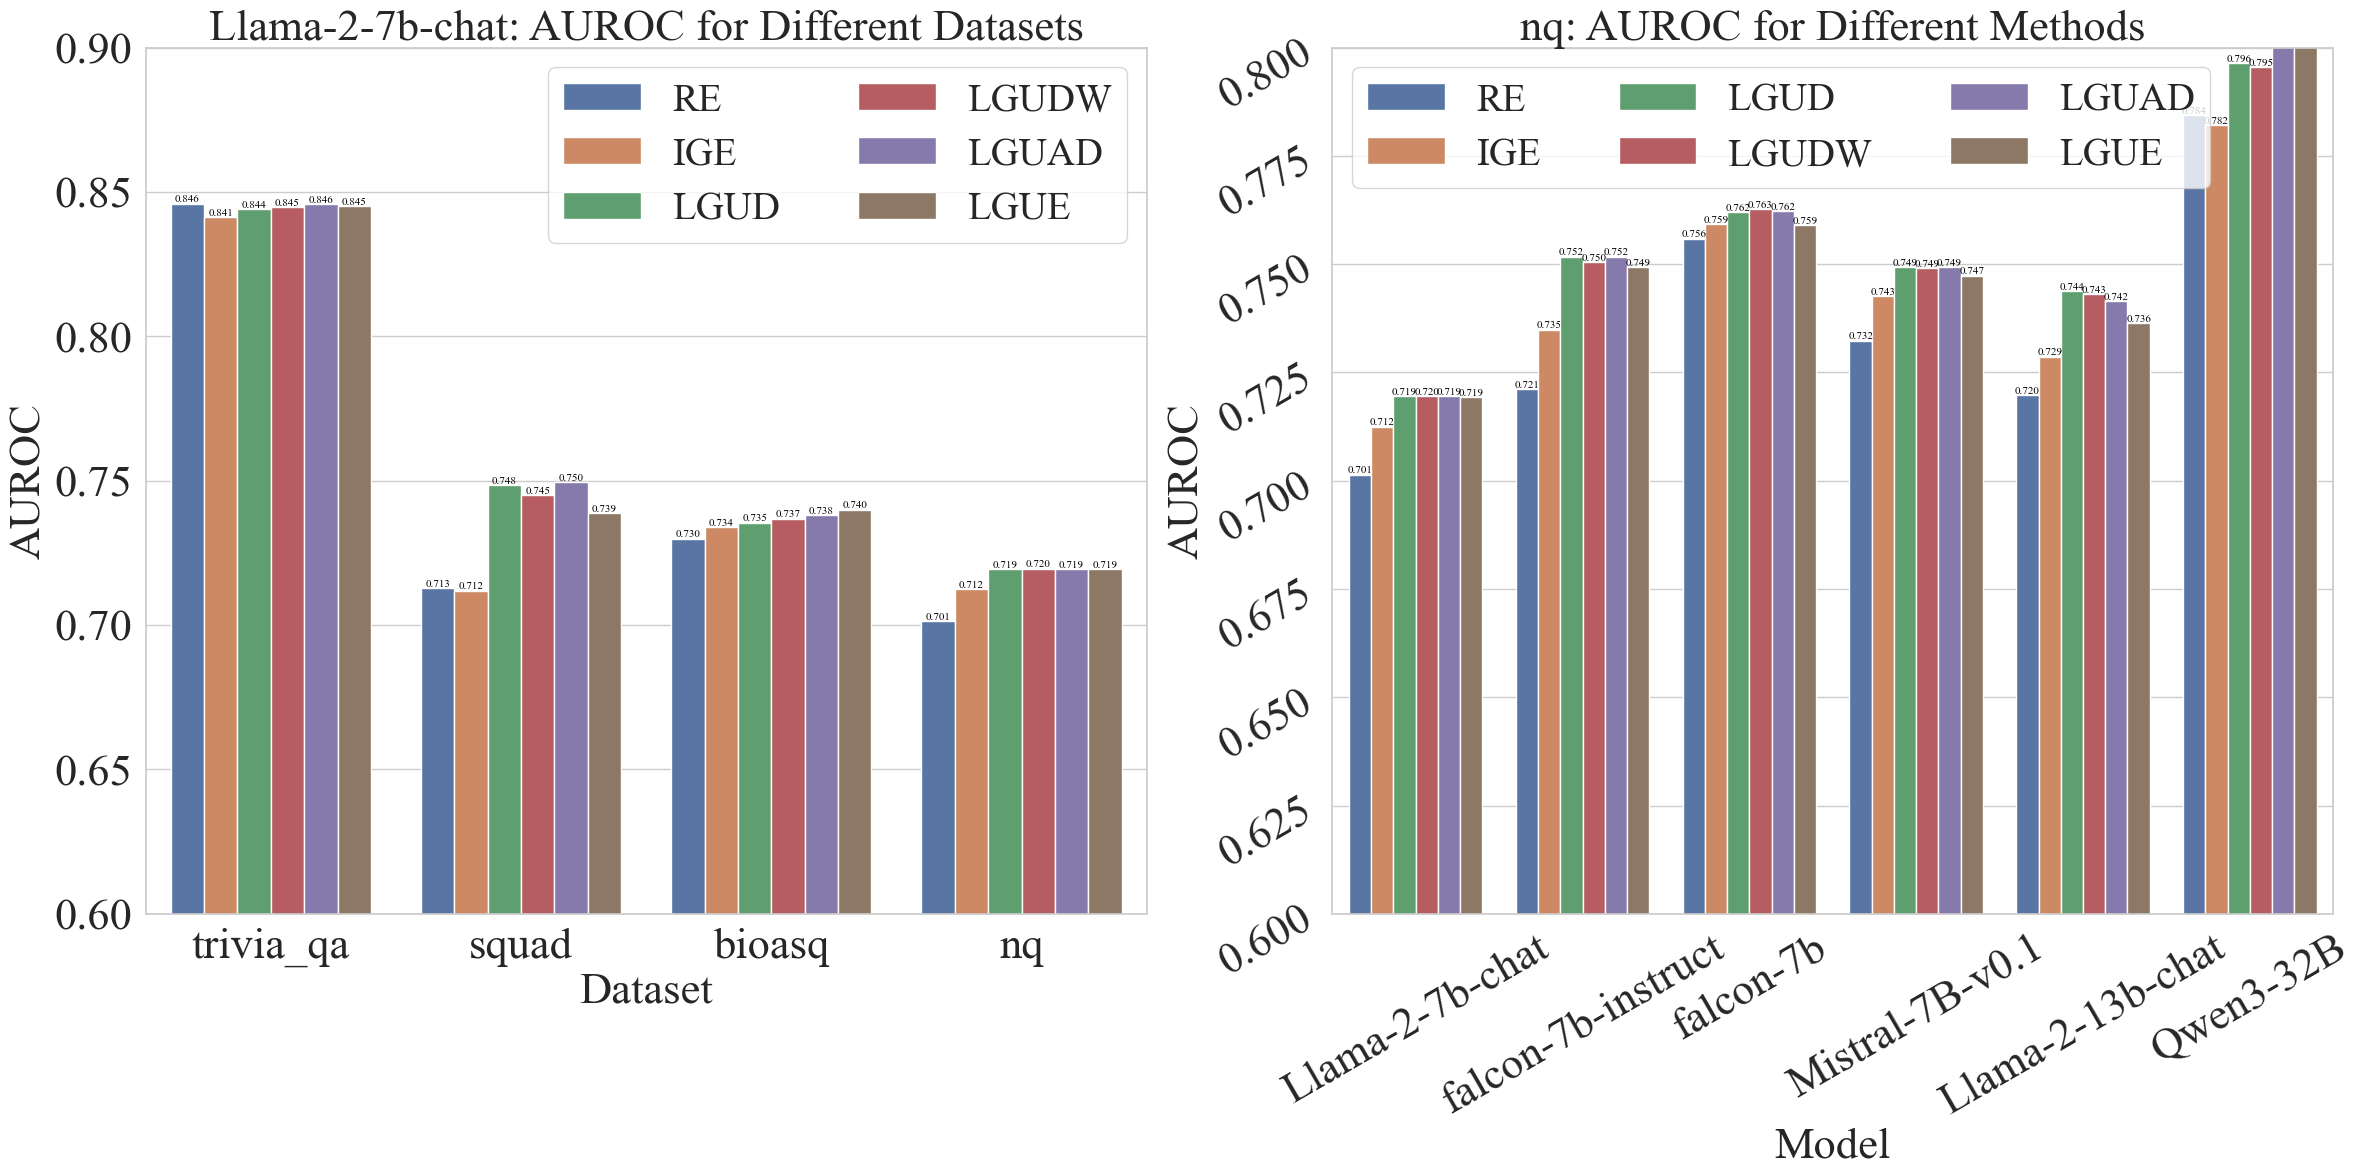

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 36
})
sns.set_theme(style="whitegrid", font="Times New Roman", font_scale=1.2)

methods_to_plot = ['RE', 'IGE', 'LGUD', 'LGUDW', 'LGUAD', 'LGUE']
# methods_to_plot = ['Discrete Semantic Entropy', 'KLE(heat)', 'Discrete Logical Graph Entropy']
df_filtered = df_auroc[df_auroc['Method'].isin(methods_to_plot)]

# 选择一个模型和一个数据集
model_to_plot = "Llama-2-7b-chat"
dataset_to_plot = "nq"
df_model = df_filtered[df_filtered["Model"] == model_to_plot]
df_dataset = df_filtered[df_filtered["Dataset"] == dataset_to_plot]

fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # 调整子图大小，宽度为16，高度为8


# 子图1：同一模型不同数据集的AUROC
bar1 = sns.barplot(
    data=df_model,
    x="Dataset",
    y="AUROC",
    hue="Method",
    ax=axes[0]
)
axes[0].set_title(f"{model_to_plot}: AUROC for Different Datasets", fontsize=32)
axes[0].set_ylabel("AUROC", fontsize=32)
axes[0].set_xlabel("Dataset", fontsize=32)
axes[0].set_ylim(0.6, 0.9)  # 设置y轴范围
axes[0].legend(loc="best", ncol=2, fontsize=28)
axes[0].tick_params(axis='both', labelsize=32)  # 横轴字体变大

# 给每个柱子标注数值
for p in bar1.patches:
    height = p.get_height()
    if not np.isnan(height):
        bar1.annotate(f'{height:.3f}', 
                      (p.get_x() + p.get_width() / 2., height), 
                      ha='center', va='bottom', fontsize=8, color='black', rotation=0)

# 子图2：同一数据集不同方法的AUROC
bar2 = sns.barplot(
    data=df_dataset,
    x="Model",
    y="AUROC",
    hue="Method",
    ax=axes[1]
)
axes[1].set_title(f"{dataset_to_plot}: AUROC for Different Methods", fontsize=32)
axes[1].set_ylabel("AUROC", fontsize=32)
axes[1].set_xlabel("Model", fontsize=32)
axes[1].set_ylim(0.6, 0.8)  # 设置y轴范围
axes[1].tick_params(axis='both', rotation=30, labelsize=32)
axes[1].legend(loc="best", ncol=3, fontsize=28)
for p in bar2.patches:
    height = p.get_height()
    if not np.isnan(height):
        bar2.annotate(f'{height:.3f}', 
                      (p.get_x() + p.get_width() / 2., height), 
                      ha='center', va='bottom', fontsize=8, color='black', rotation=0)

plt.tight_layout()
plt.savefig('wb_auroc.pdf')  # 保存图像
plt.show()